In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("cards_data.xlsx")


In [2]:
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_brand             6146 non-null   object        
 3   card_type              6146 non-null   object        
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[ns]
 6   cvv                    6146 non-null   int64         
 7   has_chip               6146 non-null   object        
 8   num_cards_issued       6146 non-null   int64         
 9   credit_limit           6146 non-null   int64         
 10  acct_open_date         6146 non-null   datetime64[ns]
 11  year_pin_last_changed  6146 non-null   int64         
 12  card_on_dark_web       6146 non-null   object        
dtypes: 

,id,client_id,card_number,expires,cvv,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
count,6146.000000,6146.000000,6.146000e+03,6146,6146.000000,6146.000000,6146.000000,6146,6146.000000
mean,3072.500000,994.939636,4.820426e+15,2020-10-08 06:30:06.443215360,506.220794,1.503091,14347.493980,2011-01-15 12:55:31.727953152,2013.436707
min,0.000000,0.000000,3.001055e+14,1997-07-01 00:00:00,0.000000,1.000000,0.000000,1991-01-01 00:00:00,2002.000000
25%,1536.250000,492.250000,4.486365e+15,2020-02-01 00:00:00,257.000000,1.000000,7042.750000,2006-10-01 00:00:00,2010.000000
50%,3072.500000,992.000000,5.108957e+15,2021-09-01 00:00:00,516.500000,1.000000,12592.500000,2010-02-15 00:00:00,2013.000000
75%,4608.750000,1495.000000,5.585237e+15,2023-05-01 00:00:00,756.000000,2.000000,19156.500000,2016-05-01 00:00:00,2017.000000
max,6145.000000,1999.000000,6.997197e+15,2024-12-01 00:00:00,999.000000,3.000000,151223.000000,2020-02-01 00:00:00,2020.000000
std,1774.341709,578.614626,1.328582e+15,NaN,289.431123,0.519191,12014.463884,NaN,4.270699


In [6]:
print(df.isnull().sum())


id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df.nunique())


id                       6146
client_id                2000
card_brand                  4
card_type                   3
card_number              6146
expires                   259
cvv                       998
has_chip                    2
num_cards_issued            3
credit_limit             3654
acct_open_date            303
year_pin_last_changed      19
card_on_dark_web            1
dtype: int64


In [11]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ","_")

In [12]:
df['high_limit_customer'] = np.where(df['credit_limit'] > 10000, 1, 0)

In [15]:
df[['credit_limit' , 'high_limit_customer']].head()

,credit_limit,high_limit_customer
0,24295,1
1,21968,1
2,46414,1
3,12400,1
4,28,0


In [22]:
df['multi_card_holder'] = np.where(df['num_cards_issued'] > 1, 1, 0)

In [23]:
df[['num_cards_issued', 'multi_card_holder']].head()

,num_cards_issued,multi_card_holder
0,2,1
1,2,1
2,2,1
3,1,0
4,1,0


In [25]:
#KPI SECTION

Total Cards : 6146


In [25]:
total_cards = df['card_number'].nunique()
print("Total Cards :", total_cards)

Total Cards : 6146


In [28]:
total_customers = df['client_id'].nunique()
print("Total Cards :", total_cards)

Total Cards : 6146


In [30]:
avg_credit_limit = round(df['credit_limit'].mean(), 2)
print ("Average Credit Limit :", avg_credit_limit)

Average Credit Limit : 14347.49


In [31]:
max_credit_limit = df['credit_limit'].max()
print("Maximum Credit Limit :", max_credit_limit)

Maximum Credit Limit : 151223


In [32]:
chip_percentage = round((df['has_chip'].value_counts(normalize =True) * 100), 2)
print("\nChip Enabled Percentage :")
print(chip_percentage)


Chip Enabled Percentage :
has_chip
YES    89.49
NO     10.51
Name: proportion, dtype: float64


In [33]:
avg_cards_issued = round(df['num_cards_issued'].mean(), 2)
print("\nAverage Cards Issued :", avg_cards_issued)


Average Cards Issued : 1.5


In [34]:
high_limit_customers = (df['high_limit_customer'].sum())
print("High Limit Customers :", high_limit_customers)

High Limit Customers : 3798


In [35]:
#Credit Limit Distribution

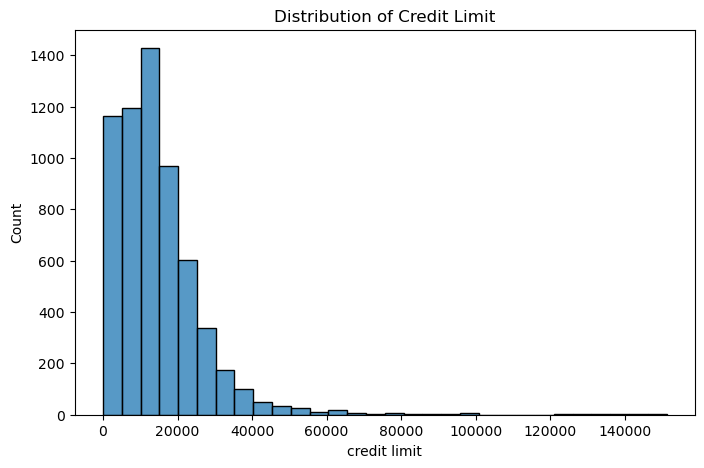

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['credit_limit'], bins=30)
plt.title("Distribution of Credit Limit")
plt.xlabel("credit limit")
plt.ylabel("Count")
plt.show()

In [39]:
#Card Brand Count

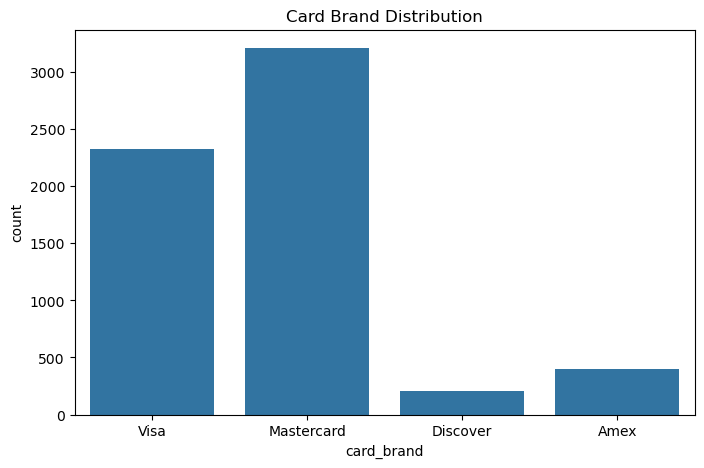

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='card_brand', data=df)
plt.title("Card Brand Distribution")
plt.show()

In [41]:
#Average Credit Limit by Card Brand

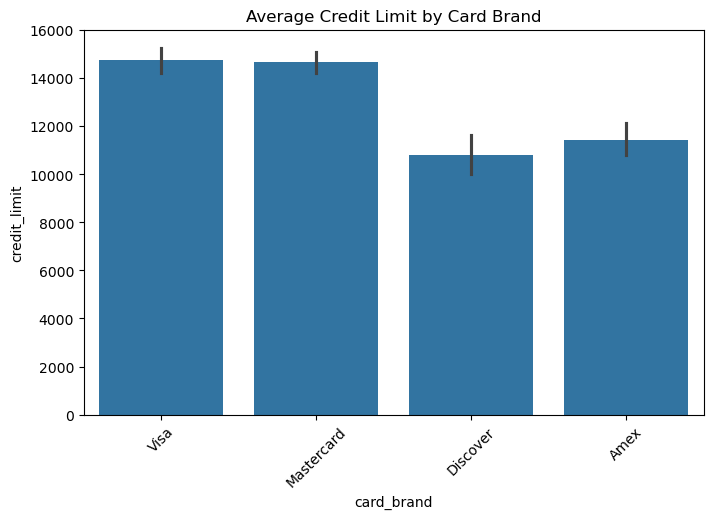

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x='card_brand', y='credit_limit', data=df)
plt.title("Average Credit Limit by Card Brand")
plt.xticks(rotation=45)
plt.show()

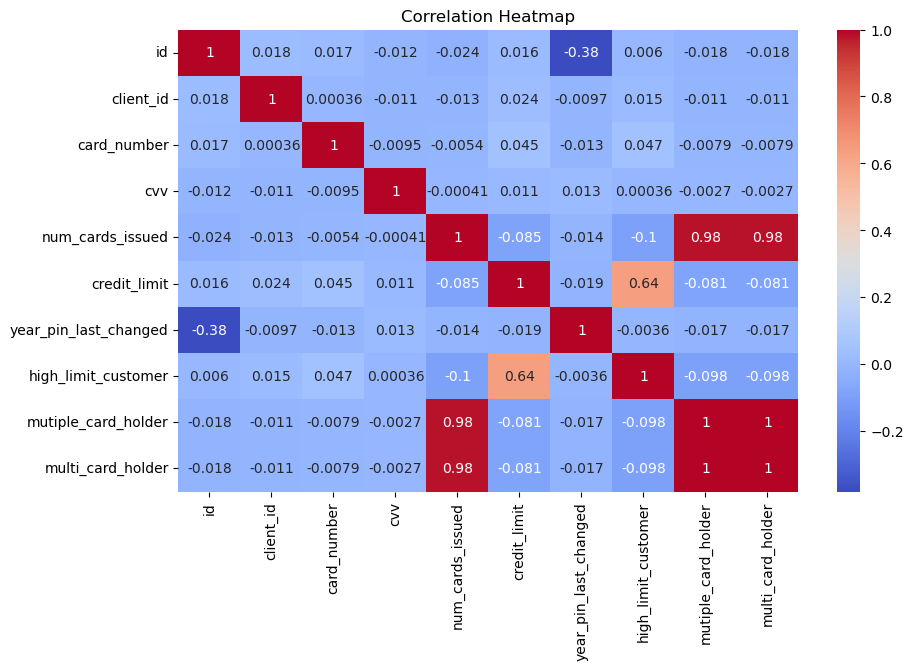

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [46]:
#OUTLIER DETECTION

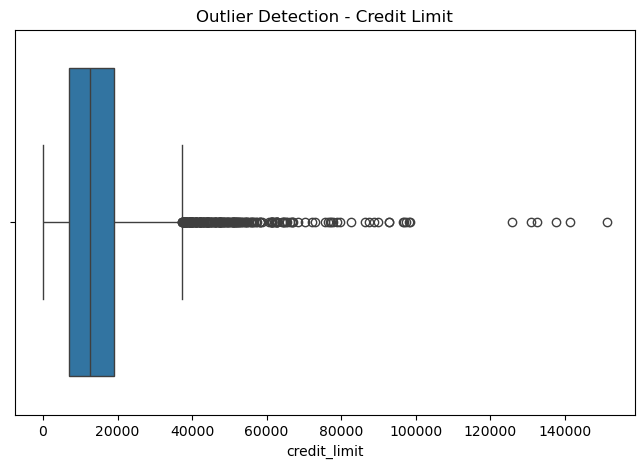

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['credit_limit'])
plt.title("Outlier Detection - Credit Limit")
plt.show()

In [48]:
#BUSINESS QUESTIONS

In [49]:
print("\nTop Card Brands by Average Credit Limit:\n")
print(df.groupby('card_brand')['credit_limit'].mean().sort_values(ascending=False))
print("\nTop Customers with Highest Credit Limit:\n")
print(df.groupby('client_id')['credit_limit'].mean().sort_values(ascending=False).head(10))


Top Card Brands by Average Credit Limit:

card_brand
Visa          14737.334910
Mastercard    14659.600187
Amex          11436.318408
Discover      10816.267943
Name: credit_limit, dtype: float64

Top Customers with Highest Credit Limit:

client_id
708     89081.000000
1223    81271.333333
278     78639.400000
777     72818.500000
1156    72153.200000
952     67600.000000
1325    67000.000000
944     65155.500000
1259    63568.833333
342     61407.000000
Name: credit_limit, dtype: float64


In [49]:
print("\nTop Card Brands by Average Credit Limit:\n")
print(df.groupby('card_brand')['credit_limit'].mean().sort_values(ascending=False))
print("\nTop Customers with Highest Credit Limit:\n")
print(df.groupby('client_id')['credit_limit'].mean().sort_values(ascending=False).head(10))


Top Card Brands by Average Credit Limit:

card_brand
Visa          14737.334910
Mastercard    14659.600187
Amex          11436.318408
Discover      10816.267943
Name: credit_limit, dtype: float64

Top Customers with Highest Credit Limit:

client_id
708     89081.000000
1223    81271.333333
278     78639.400000
777     72818.500000
1156    72153.200000
952     67600.000000
1325    67000.000000
944     65155.500000
1259    63568.833333
342     61407.000000
Name: credit_limit, dtype: float64


In [50]:
df.to_csv("cards_data_cleaned.csv", index=False)